# Stable Diffusion 1.5 VAE Reconstruction Test

This notebook loads a few images from `data/raw/flir_private_proxy_alignment_v18`, runs them through the Stable Diffusion 1.5 VAE, and compares the original thermal frame with its reconstruction.

Notes:
- the dataset images are grayscale `.npy` arrays,
- SD 1.5's VAE expects 3-channel inputs, so we repeat the thermal frame across RGB,
- the decoded image is converted back to grayscale for side-by-side inspection.


In [2]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import AutoencoderKL


def resolve_repo_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not resolve repository root from the current working directory.")


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = REPO_ROOT / "data" / "raw" / "flir_private_proxy_alignment_v18"
SPLIT = "train"
NUM_SAMPLES = 6
MODEL_ID = "runwayml/stable-diffusion-v1-5"

device = "cuda:1" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"REPO_ROOT={REPO_ROOT}")
print(f"DATA_ROOT={DATA_ROOT}")
print(f"device={device}, dtype={dtype}")


/export/livia/home/vision/Fbassignana/miniconda3/envs/diffusers-dev/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


REPO_ROOT=/projets/Fbassignana/diffusers_try/flow_matching_trial
DATA_ROOT=/projets/Fbassignana/diffusers_try/flow_matching_trial/data/raw/flir_private_proxy_alignment_v18
device=cuda:1, dtype=torch.float32


In [3]:
image_paths = sorted((DATA_ROOT / SPLIT).glob("*.npy"))[:NUM_SAMPLES]
if not image_paths:
    raise FileNotFoundError(f"No .npy images found under {(DATA_ROOT / SPLIT)!s}")

vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=dtype).to(device)
vae.eval()

print(f"Loaded {len(image_paths)} images from split={SPLIT!r}")
print(f"First sample: {image_paths[0].name}")
vae


Loaded 6 images from split='train'
First sample: video-24ysbPEGoEKKDvRt6-frame-000000-4C4FHWxwNaMyohLZt.npy


AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (nonlinearity): SiLU()
          )
        )
        (downsamplers): ModuleList(
          (0): Downsample2D(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (c

In [6]:
def load_grayscale_tensor(path: Path) -> tuple[np.ndarray, torch.Tensor]:
    arr = np.load(path)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D grayscale array, got shape={arr.shape} for {path}")

    arr = arr.astype(np.float32)
    arr_01 = arr / 255.0 if arr.max() > 1.0 else np.clip(arr, 0.0, 1.0)
    rgb_01 = np.repeat(arr_01[None, :, :], 3, axis=0)
    tensor = torch.from_numpy(rgb_01).unsqueeze(0)
    tensor = tensor * 2.0 - 1.0
    return arr_01, tensor


@torch.no_grad()
def reconstruct_with_vae(x: torch.Tensor) -> np.ndarray:
    x = x.to(device=device, dtype=dtype)
    posterior = vae.encode(x).latent_dist
    latents = posterior.sample() * vae.config.scaling_factor
    print(f"Latents shape: {latents.shape}, min={latents.min():.4f}, max={latents.max():.4f}")
    decoded = vae.decode(latents / vae.config.scaling_factor).sample
    decoded = ((decoded.clamp(-1.0, 1.0) + 1.0) / 2.0).squeeze(0)
    decoded_gray = decoded.mean(dim=0).float().cpu().numpy()
    return np.clip(decoded_gray, 0.0, 1.0)


records = []
for path in image_paths:
    original, x = load_grayscale_tensor(path)
    reconstruction = reconstruct_with_vae(x)
    mae = float(np.mean(np.abs(reconstruction - original)))
    mse = float(np.mean((reconstruction - original) ** 2))
    records.append(
        {
            "path": path,
            "original": original,
            "reconstruction": reconstruction,
            "mae": mae,
            "mse": mse,
        }
    )

print(f"mean MAE: {np.mean([r['mae'] for r in records]):.4f}")
print(f"mean MSE: {np.mean([r['mse'] for r in records]):.4f}")


Latents shape: torch.Size([1, 4, 64, 80]), min=-4.9461, max=5.5815
Latents shape: torch.Size([1, 4, 64, 80]), min=-6.8352, max=5.9494
Latents shape: torch.Size([1, 4, 64, 80]), min=-5.6170, max=6.9434
Latents shape: torch.Size([1, 4, 64, 80]), min=-6.2636, max=6.8954
Latents shape: torch.Size([1, 4, 64, 80]), min=-8.3687, max=8.3486
Latents shape: torch.Size([1, 4, 64, 80]), min=-9.1165, max=10.8407
mean MAE: 0.0235
mean MSE: 0.0011


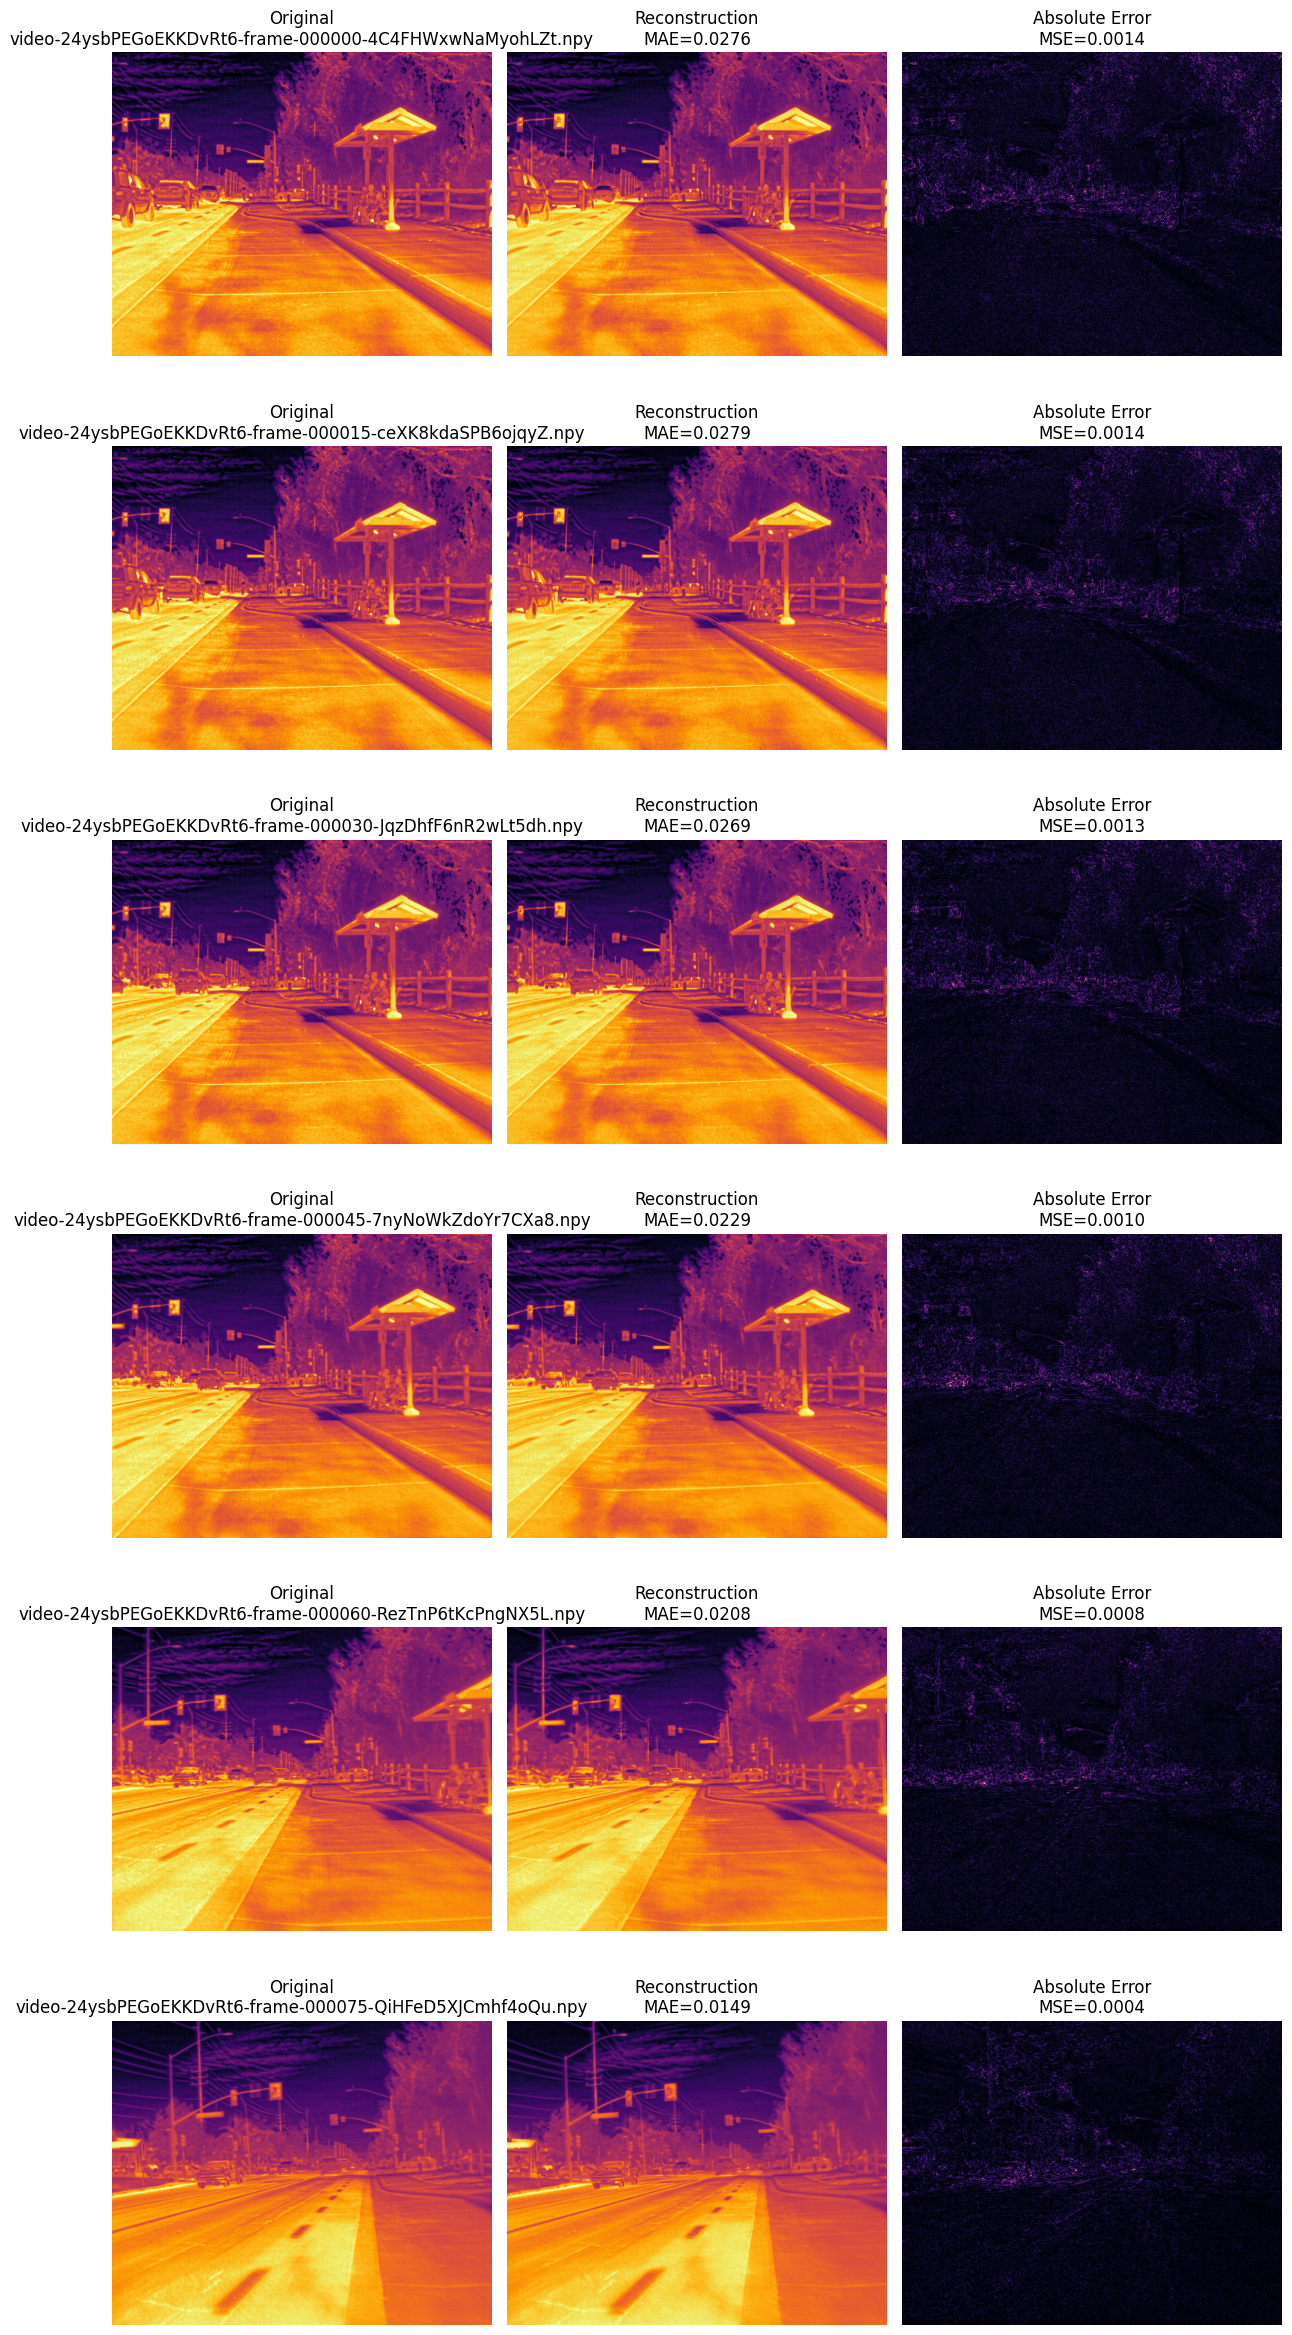

In [7]:
rows = len(records)
fig, axes = plt.subplots(rows, 3, figsize=(12, 4 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row, record in enumerate(records):
    original = record["original"]
    reconstruction = record["reconstruction"]
    error = np.abs(reconstruction - original)

    axes[row, 0].imshow(original, cmap="inferno")
    axes[row, 0].set_title(f"Original\n{record['path'].name}")

    axes[row, 1].imshow(reconstruction, cmap="inferno")
    axes[row, 1].set_title(f"Reconstruction\nMAE={record['mae']:.4f}")

    axes[row, 2].imshow(error, cmap="magma")
    axes[row, 2].set_title(f"Absolute Error\nMSE={record['mse']:.4f}")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()
